### __Nama__ : *Muhammad Maulana Rosyid*  
### &emsp;&emsp;&emsp;*Rifat Qoyyim Sidik*  
### __Kelompok__ : 1 - UT

---

### Tahap 1 - Data Preparation & Overview

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# List file .csv di folder
path = 'Dataset Tugas Data Science M4/'
files = [f for f in os.listdir(path) if f.endswith('.csv')]

# Load file
if files:
    full_path = os.path.join(path, files[0])
    df = pd.read_csv(full_path)
    print(f"Berhasil memuat file: {files[0]}")
else:
    print("Tidak ada file .csv yang ditemukan di folder tersebut.")

# Konversi kolom tanggal
df['review_date'] = pd.to_datetime(df['review_date'])

# Overview & Cleaning Dasar
print("\n--- Info Dataset ---")
print(df.info())

# jumlah missing values tiap kolom
print("\n--- Info Missing Value ---")
missing_values = df.isnull().sum()

print(missing_values)

# Menampilkan 5 data teratas
df.head()

Berhasil memuat file: tokopedia_product_reviews_2025.csv

--- Info Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 65544 entries, 0 to 65543
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   review_text       65543 non-null  str           
 1   review_date       65543 non-null  datetime64[us]
 2   review_id         65543 non-null  float64       
 3   product_name      65543 non-null  str           
 4   product_category  65543 non-null  str           
 5   product_variant   26749 non-null  str           
 6   product_price     65543 non-null  float64       
 7   product_url       65543 non-null  str           
 8   product_id        65543 non-null  float64       
 9   rating            65543 non-null  float64       
 10  sold_count        65543 non-null  float64       
 11  shop_id           65543 non-null  float64       
 12  sentiment_label   65543 non-null  str           
dtypes: datet

,review_text,review_date,review_id,product_name,product_category,product_variant,product_price,product_url,product_id,rating,sold_count,shop_id,sentiment_label
0,baru sekali ini terima brg dr belanja online d...,2024-12-22,1.134256e+09,Telur Ayam Kampung Asli - Telur Mengandung Ome...,Makanan & Minuman,Box Polos,87000.0,https://www.tokopedia.com/indofarmproduct/telu...,4.601033e+09,5.0,1000000.0,8672687.0,positive
1,cocok bgt aku sama telur nya. nga Amis menurut...,2025-02-25,1.242585e+09,Telur Ayam Kampung Asli - Telur Mengandung Ome...,Makanan & Minuman,Box Polos,87000.0,https://www.tokopedia.com/indofarmproduct/telu...,4.601033e+09,5.0,1000000.0,8672687.0,positive
2,Telornya sudah sampai di rumah dengan kemasan ...,2025-07-15,1.573445e+09,Telur Ayam Kampung Asli - Telur Mengandung Ome...,Makanan & Minuman,Box Polos,87000.0,https://www.tokopedia.com/indofarmproduct/telu...,4.601033e+09,5.0,1000000.0,8672687.0,positive
3,Telor sudah diterima dengan baik dan tidak ada...,2025-07-20,1.581729e+09,Telur Ayam Kampung Asli - Telur Mengandung Ome...,Makanan & Minuman,Box Polos,87000.0,https://www.tokopedia.com/indofarmproduct/telu...,4.601033e+09,5.0,1000000.0,8672687.0,positive
4,"Alhamdulillah penjual amanah,Telor nya terbaik...",2023-04-24,8.810414e+08,Telur Ayam Kampung Asli - Telur Mengandung Ome...,Makanan & Minuman,Box Full Design,87000.0,https://www.tokopedia.com/indofarmproduct/telu...,4.601033e+09,5.0,1000000.0,8672687.0,positive


Program berhasil melakukan pemindaian pada direktori Dataset Tugas Data Science M4/ dan memuat dataset ulasan produk Tokopedia. Data terdiri dari 13 kolom, di mana kolom review_date telah berhasil dikonversi menjadi format datetime untuk kebutuhan analisis berbasis waktu nantinya. Secara sekilas, dataset ini memiliki informasi yang lengkap mulai dari harga, jumlah terjual, hingga label sentimen.

---

### Tahap 2 - Analisis Univariat (Distribusi & Frekuensi)

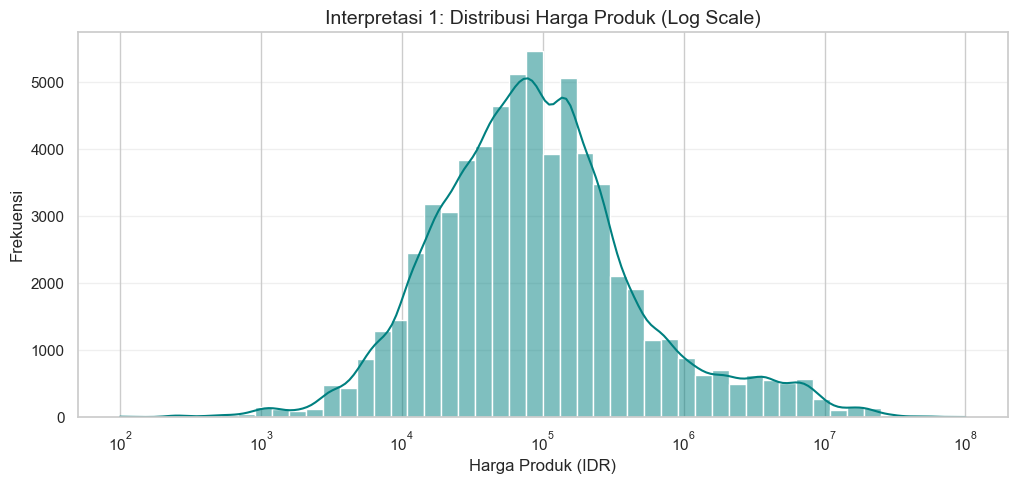

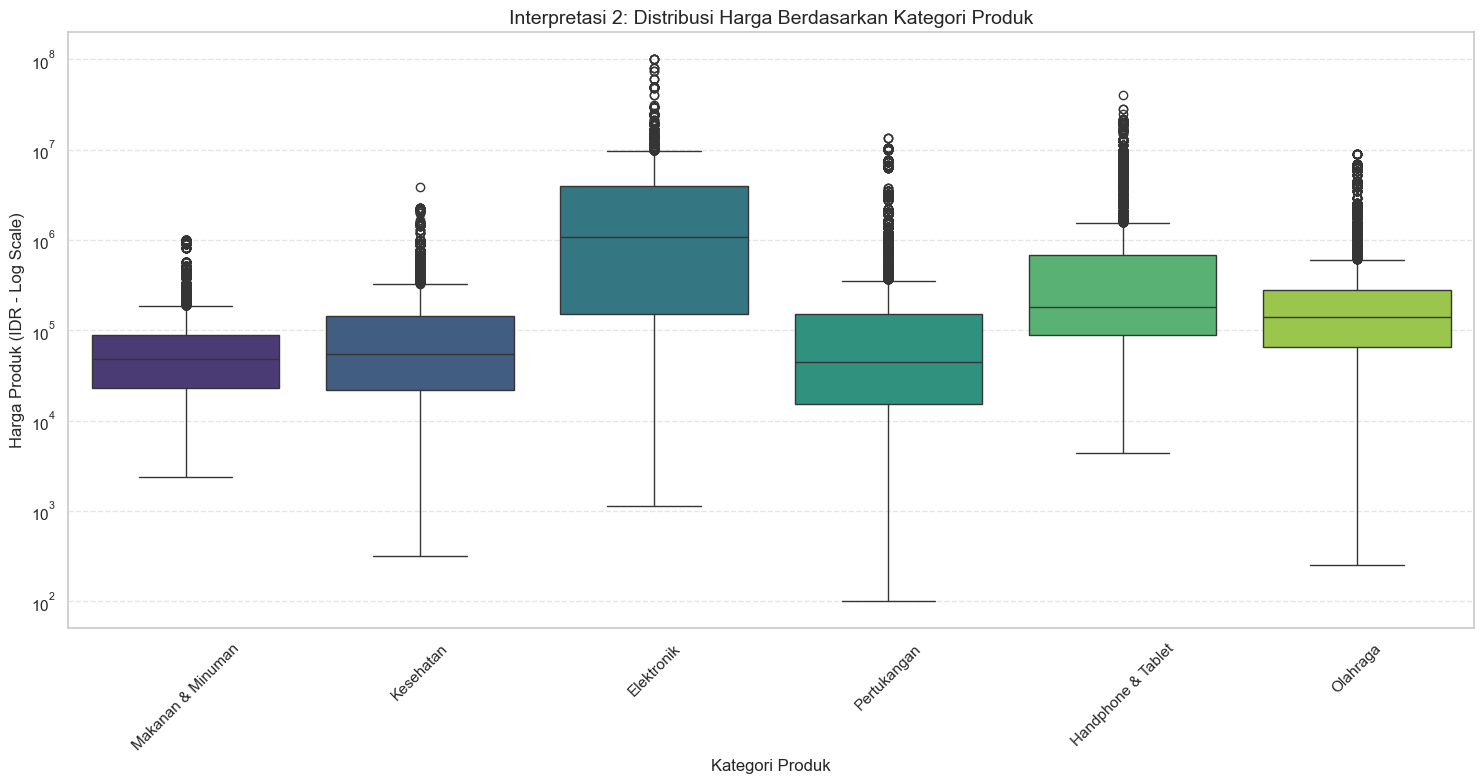

,Nama Kategori,Jumlah,Persentase (%)
0,Makanan & Minuman,17859,27.25
1,Olahraga,15600,23.80
2,Pertukangan,11500,17.55
3,Kesehatan,8959,13.67
4,Handphone & Tablet,7423,11.33


In [27]:
# --- Interpretasi 1: Distribusi Harga Produk (Histogram) ---
plt.figure(figsize=(12, 5))
sns.histplot(df['product_price'], bins=50, kde=True, color='teal', log_scale=True)
plt.title('Interpretasi 1: Distribusi Harga Produk (Log Scale)', fontsize=14)
plt.xlabel('Harga Produk (IDR)')
plt.ylabel('Frekuensi')
plt.grid(axis='y', alpha=0.3)
plt.show()

# --- Interpretasi 2: Perbandingan Kategori dengan Harga (Boxplot) ---
plt.figure(figsize=(15, 8))

# Menentukan ukuran kanvas (figure) agar grafik cukup lebar dan informasi tidak berhimpitan.
sns.boxplot(
    data=df, 
    x='product_category', 
    y='product_price', 
    hue='product_category',
    palette='viridis', 
    legend=False
)

plt.yscale('log')
plt.title('Interpretasi 2: Distribusi Harga Berdasarkan Kategori Produk', fontsize=14)
plt.xlabel('Kategori Produk')
plt.ylabel('Harga Produk (IDR - Log Scale)')
plt.xticks(rotation=45)
plt.grid(axis='y', ls='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Hitung Frekuensi Kategori
summary_table = df["product_category"].value_counts().reset_index()
summary_table.columns = ['Nama Kategori', 'Jumlah']
summary_table['Persentase (%)'] = (summary_table['Jumlah'] / summary_table['Jumlah'].sum() * 100).round(2)

display(summary_table.head())

#### Interpretasi 1:
Distribusi harga produk menunjukkan konsentrasi massa data pada rentang harga tertentu. Dengan menggunakan skala logaritmik, terlihat bahwa produk memiliki variasi harga yang sangat luas, namun tetap memiliki titik puncak (mode) yang menunjukkan segmen harga paling populer di Tokopedia untuk brand aggregator ini.

#### Interpretasi 2:
Melalui Boxplot, kita dapat melihat bahwa kategori produk memiliki sebaran harga yang berbeda-beda. Kategori tertentu mungkin memiliki rentang harga yang lebih stabil (box yang pendek), sementara kategori lain memiliki banyak outlier (titik-titik di atas whisker) yang mengindikasikan adanya produk premium atau eksklusif di dalam kategori tersebut.

---

### Tahap 3 - Deteksi Outlier (Anomali Data)

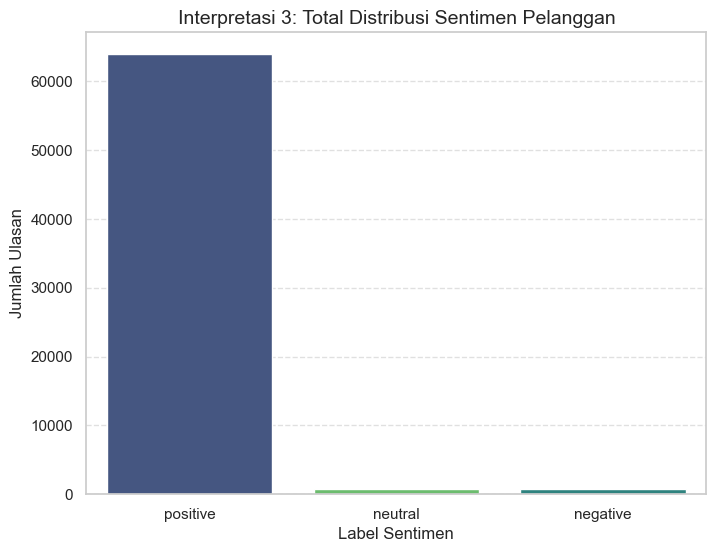

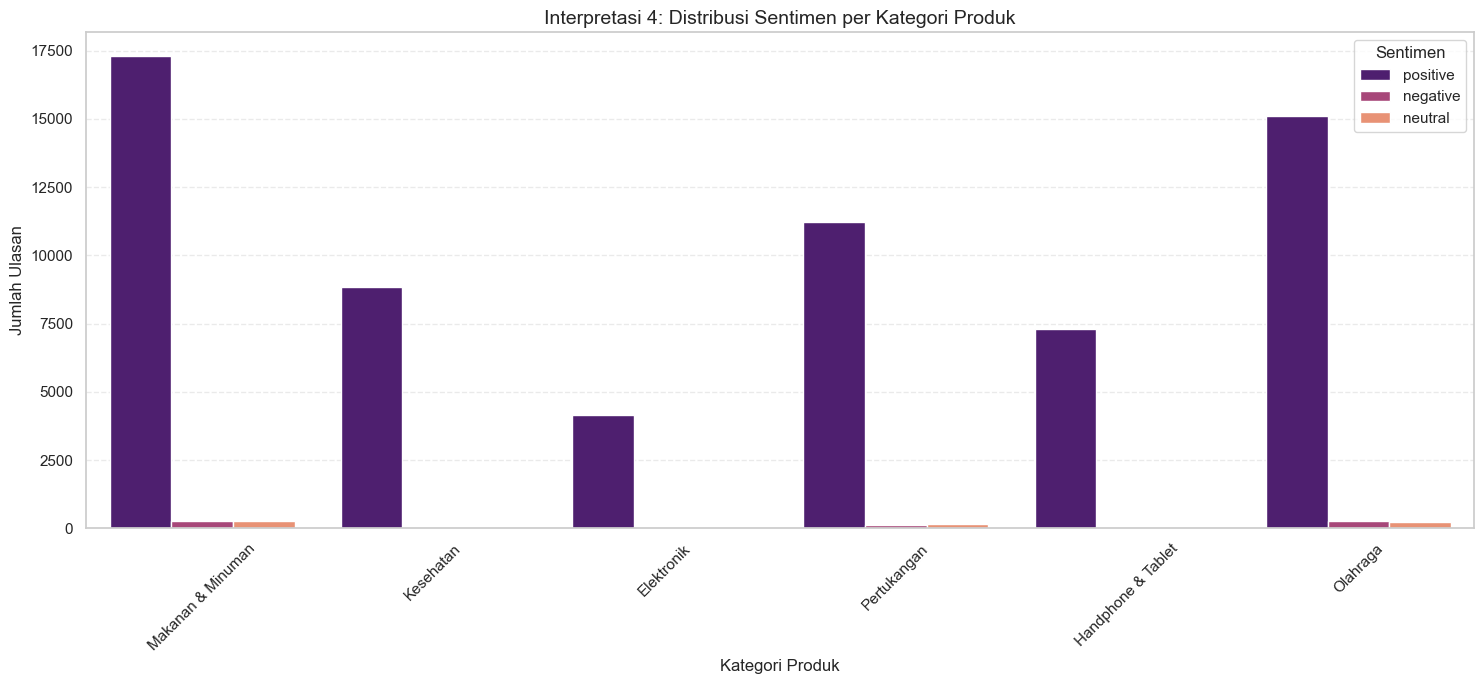

In [21]:
# --- Interpretasi 3: Total Distribusi Sentimen (Bar Plot) ---
plt.figure(figsize=(8, 6))

# Menghitung urutan agar grafik lebih rapi
sentiment_counts = df['sentiment_label'].value_counts()
sns.countplot(data=df, x='sentiment_label', order=sentiment_counts.index, palette='viridis', hue='sentiment_label', legend=False)

plt.title('Interpretasi 3: Total Distribusi Sentimen Pelanggan', fontsize=14)
plt.xlabel('Label Sentimen')
plt.ylabel('Jumlah Ulasan')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

# --- Interpretasi 4: Sentimen Berdasarkan Kategori Produk (Stacked/Grouped Bar Plot) ---
plt.figure(figsize=(15, 7))

# Menggunakan countplot dengan hue kategori produk
sns.countplot(data=df, x='product_category', hue='sentiment_label', palette='magma')

plt.title('Interpretasi 4: Distribusi Sentimen per Kategori Produk', fontsize=14)
plt.xlabel('Kategori Produk')
plt.ylabel('Jumlah Ulasan')
plt.xticks(rotation=45)
plt.legend(title='Sentimen', loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

#### Interpretasi 3:
Grafik batang menunjukkan dominasi sentimen tertentu pada seluruh ulasan produk. Jika sentimen 'Positive' terlihat jauh lebih tinggi, ini menandakan bahwa secara umum pelanggan merasa puas dengan produk yang dikelola oleh aggregator. Namun, keberadaan sentimen 'Negative' tetap perlu diperhatikan sebagai bahan evaluasi kualitas.

#### Interpretasi 4:
Melalui visualisasi per kategori, kita dapat melihat kategori mana yang paling banyak menyumbang sentimen positif dan mana yang memiliki risiko sentimen negatif lebih tinggi. Misalnya, kategori dengan volume ulasan besar cenderung memiliki variasi sentimen yang lebih beragam. Hal ini membantu bisnis untuk fokus melakukan perbaikan pada kategori spesifik yang memiliki proporsi negatif cukup menonjol.

---

### Tahap 4 - Analisis Multivariat (Tren & Korelasi)

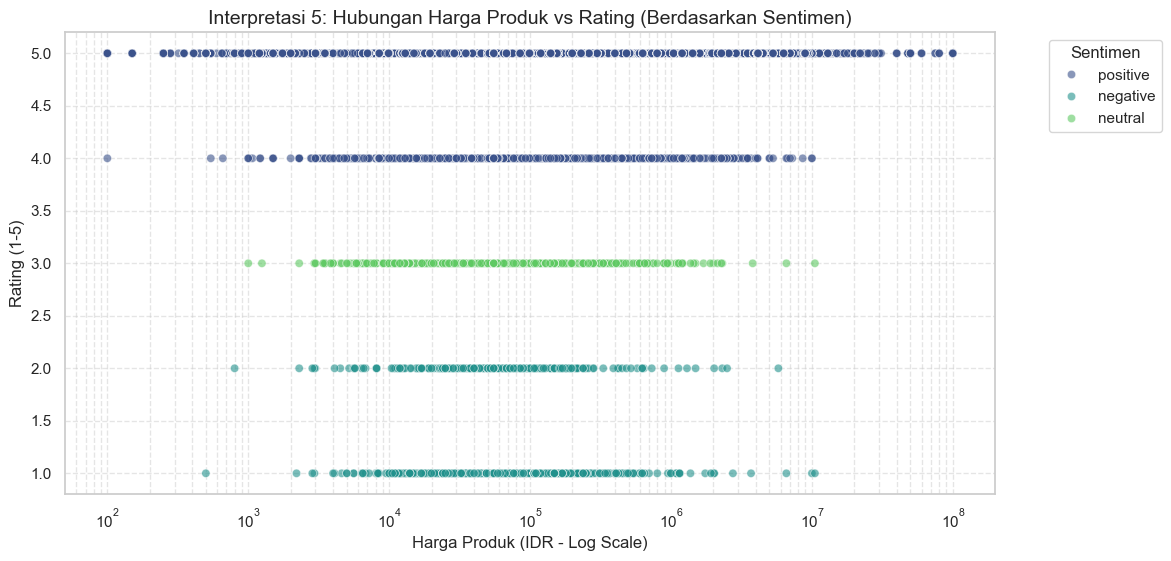

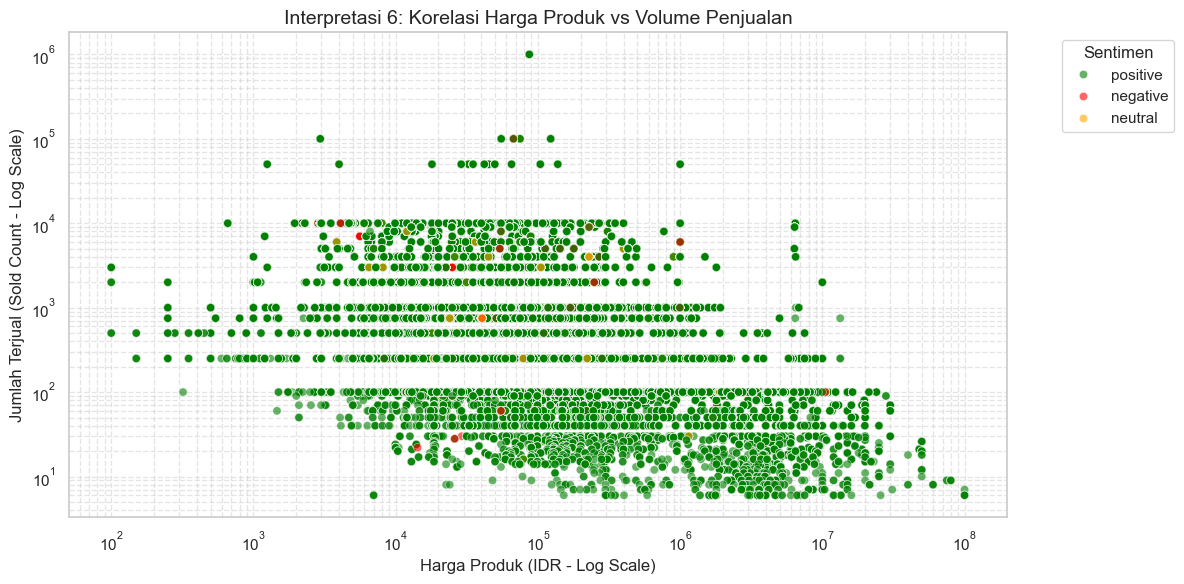

In [22]:
# --- Interpretasi 5: Hubungan Rating dan Harga berdasarkan Sentimen ---
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=df, 
    x='product_price', 
    y='rating', 
    hue='sentiment_label', 
    alpha=0.6,
    palette='viridis'
)

plt.xscale('log') # Skala logaritmik karena rentang harga yang lebar
plt.title('Interpretasi 5: Hubungan Harga Produk vs Rating (Berdasarkan Sentimen)', fontsize=14)
plt.xlabel('Harga Produk (IDR - Log Scale)')
plt.ylabel('Rating (1-5)')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(title='Sentimen', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# --- Interpretasi 6: Hubungan Harga dan Volume Penjualan ---
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=df, 
    x='product_price', 
    y='sold_count', 
    hue='sentiment_label', 
    alpha=0.6,
    palette={'positive': 'green', 'neutral': 'orange', 'negative': 'red'}
)

plt.xscale('log')
plt.yscale('log') # Menggunakan log scale pada kedua sumbu karena perbedaan nilai yang ekstrem
plt.title('Interpretasi 6: Korelasi Harga Produk vs Volume Penjualan', fontsize=14)
plt.xlabel('Harga Produk (IDR - Log Scale)')
plt.ylabel('Jumlah Terjual (Sold Count - Log Scale)')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(title='Sentimen', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#### Interpretasi 5:
Scatter plot menunjukkan bahwa rating tinggi (4-5) tersebar di seluruh rentang harga, baik produk murah maupun mahal. Namun, ulasan dengan sentimen negatif cenderung berkumpul pada produk dengan rating rendah, tanpa memandang harga. Hal ini mengindikasikan bahwa harga tinggi tidak menjamin sentimen positif jika kualitas produk atau ekspektasi pelanggan tidak terpenuhi.

#### Interpretasi 6:
Berdasarkan grafik, terlihat korelasi di mana produk dengan harga lebih rendah cenderung memiliki volume penjualan (sold_count) yang jauh lebih masif (mencapai jutaan terjual). Menariknya, produk dengan penjualan tertinggi ("laris manis") hampir seluruhnya didominasi oleh titik berwarna hijau (sentimen positif), menunjukkan bahwa produk yang mampu terjual dalam jumlah besar biasanya adalah produk yang sudah terbukti kualitasnya di mata pelanggan.

---

### Tahap 5: Kesimpulan & Rekomendasi Bisnis (Final Mini Report)
Berdasarkan seluruh rangkaian analisis visual ulasan produk Tokopedia 2025, berikut adalah kesimpulan akhir dan rekomendasi strategis untuk brand aggregator:

#### 1. Insight Bisnis Utama
Sensitivitas Harga vs Volume Penjualan: Ditemukan adanya hubungan negatif yang jelas antara harga produk dengan jumlah penjualan. Produk dengan harga yang lebih terjangkau secara konsisten mencatatkan volume penjualan yang jauh lebih tinggi. Hal ini mengonfirmasi bahwa pasar didominasi oleh konsumen yang sangat sensitif terhadap harga dan lebih memilih produk dengan nilai kompetitif.

Kualitas sebagai Penentu Kepuasan: Sentimen pelanggan tidak memiliki korelasi linear yang kuat dengan harga produk. Baik produk kategori budget maupun luxury memiliki peluang yang sama untuk mendapatkan sentimen positif maupun negatif. Ini mengindikasikan bahwa kepuasan pelanggan lebih didorong oleh kualitas produk dan kesesuaian ekspektasi, bukan semata-mata karena harga barang tersebut murah atau mahal.

#### 2. Actionable Recommendation untuk Seller
Optimasi Strategi Harga (Pricing Strategy): Seller disarankan untuk menetapkan harga yang kompetitif, terutama pada kategori produk fast-moving (volume tinggi). Penggunaan strategi seperti bundling, diskon kuantitas, atau promo musiman sangat efektif untuk meningkatkan daya tarik di mata konsumen yang sensitif harga.

Fokus pada "Value for Money": Mengingat sentimen tidak bergantung pada harga, seller harus memastikan setiap produk memberikan nilai yang sepadan. Produk mahal tetap akan mendapat sentimen positif jika kualitas fisik, akurasi deskripsi, dan layanan purna jual memenuhi ekspektasi premium pelanggan.

Monitoring Produk Laris Ber-sentimen Negatif: Produk yang memiliki sold_count tinggi namun mulai menunjukkan tren sentimen negatif harus menjadi prioritas utama untuk dievaluasi. Seller perlu membedah ulasan spesifik untuk mengidentifikasi titik lemah (misalnya: penurunan kualitas bahan atau kendala pengiriman) guna melindungi reputasi jangka panjang toko.

---